# Video Game Sales Analysis
## Notebook 3: Business Insights and Market Strategy

### Purpose

The purpose of this notebook is to build on the exploratory findings
from Notebook 2 and identify patterns that can support business
decision-making.

The analysis focuses on:

- Identifying high-performing genre and platform combinations
- Examining differences in regional market preferences
- Evaluating publisher performance across market segments
- Identifying historically strong market opportunities
- Translating analytical findings into actionable business recommendations

### Business Question

Which combinations of genre, platform, publisher, and geographic market
have historically been associated with stronger video game sales
performance?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("vgsales_clean.csv")

df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 2. Genre and Platform Performance

This analysis examines the relationship between game genre and platform
to identify combinations associated with the highest historical global
sales.

In [4]:
genre_platform_sales = (
    df.groupby(["Genre", "Platform"])["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)

genre_platform_sales.head(15)

Genre         Platform
Action        PS3         304.02
Sports        Wii         289.95
Shooter       X360        277.23
Action        PS2         272.43
Sports        PS2         262.64
Action        X360        239.67
Misc          Wii         217.43
Shooter       PS3         195.80
Racing        PS2         154.21
Misc          DS          137.67
Sports        X360        137.43
              PS3         134.91
Simulation    DS          131.65
Role-Playing  DS          126.56
Action        PS          125.74
Name: Global_Sales, dtype: float64

### Initial Genre-Platform Insight

The strongest genre-platform combinations differ across gaming
platforms. Action games on PS3 generated the highest cumulative sales,
followed by Sports games on Wii and Shooter games on Xbox 360.

This suggests that genre performance may depend partly on the platform
on which games are released, rather than genre performance being
consistent across all platforms.

In [5]:
genre_platform_count = (
    df.groupby(["Genre", "Platform"])
    .size()
    .sort_values(ascending=False)
)

genre_platform_count.head(15)

Genre       Platform
Sports      PS2         391
Misc        DS          389
Action      PS3         373
            PS2         345
            DS          335
            X360        318
Simulation  DS          280
Misc        Wii         272
Sports      Wii         256
Adventure   DS          238
Puzzle      DS          236
Action      Wii         230
Sports      PS          221
Misc        PS2         218
Action      PSP         217
dtype: int64

In [6]:
genre_platform_median = (
    df.groupby(["Genre", "Platform"])["Global_Sales"]
    .median()
    .sort_values(ascending=False)
)

genre_platform_median.head(15)

Genre      Platform
Adventure  NES         4.380
Racing     GB          2.275
Platform   GB          2.195
Sports     NES         2.055
Racing     NES         2.050
Adventure  GB          1.860
Misc       NES         1.795
Platform   GEN         1.760
Fighting   NES         1.725
Action     NES         1.640
Platform   SCD         1.500
Fighting   GEN         1.340
Platform   DC          1.270
Shooter    NES         1.270
           PS4         1.260
Name: Global_Sales, dtype: float64

In [7]:
genre_platform_summary = (
    df.groupby(["Genre", "Platform"])
    .agg(
        Game_Count=("Global_Sales", "size"),
        Total_Sales=("Global_Sales", "sum"),
        Median_Sales=("Global_Sales", "median")
    )
    .reset_index()
)

genre_platform_summary.head()

,Genre,Platform,Game_Count,Total_Sales,Median_Sales
0,Action,2600,55,26.39,0.380
1,Action,3DS,180,56.61,0.105
2,Action,DC,3,1.26,0.080
3,Action,DS,335,114.16,0.120
4,Action,GB,6,7.92,1.020


In [8]:
reliable_combinations = genre_platform_summary[
    genre_platform_summary["Game_Count"] >= 50
]

In [9]:
reliable_combinations = (
    reliable_combinations
    .sort_values("Median_Sales", ascending=False)
)

reliable_combinations.head(15)

,Genre,Platform,Game_Count,Total_Sales,Median_Sales
210,Shooter,PS3,155,195.80,0.570
63,Fighting,PS3,76,51.70,0.485
182,Role-Playing,PS,97,78.30,0.450
219,Shooter,X360,197,277.23,0.410
111,Platform,PS2,101,72.11,0.400
0,Action,2600,55,26.39,0.380
12,Action,PS2,345,272.43,0.360
71,Fighting,X360,65,37.64,0.360
194,Role-Playing,X360,75,71.97,0.330
119,Platform,Wii,57,90.68,0.330


### Genre-Platform Performance Insight

After excluding genre-platform combinations with fewer than 50 games,
Shooter games on PS3 had the highest median global sales per title.

Although Action games on PS3 generated greater cumulative sales,
Shooter games on PS3 achieved substantially higher median sales per
game. Shooter games on Xbox 360 also showed strong per-title
performance.

These results reinforce the distinction between total market sales and
typical title performance. High cumulative sales can result from a
large number of releases, while median sales provide insight into the
performance of a typical game within a market segment.

In [10]:
top_10_reliable = reliable_combinations.head(10)

In [11]:
top_10_reliable = top_10_reliable.copy()

top_10_reliable["Genre_Platform"] = (
    top_10_reliable["Genre"] + " - " + top_10_reliable["Platform"]
)

<Figure size 1000x600 with 0 Axes>

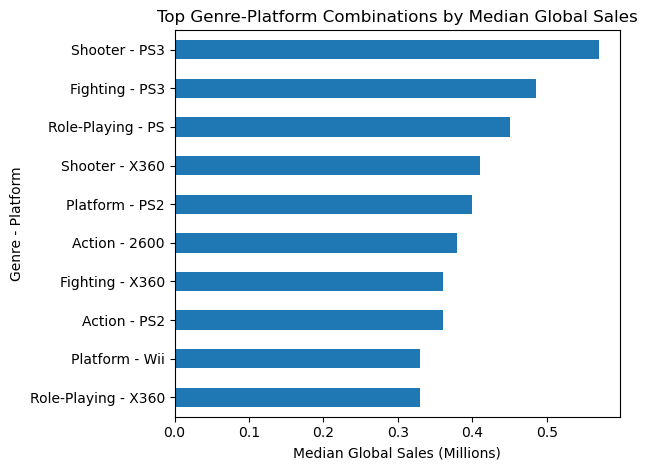

In [12]:
plt.figure(figsize=(10, 6))

top_10_reliable.sort_values("Median_Sales").plot(
    x="Genre_Platform",
    y="Median_Sales",
    kind="barh",
    legend=False
)

plt.title("Top Genre-Platform Combinations by Median Global Sales")
plt.xlabel("Median Global Sales (Millions)")
plt.ylabel("Genre - Platform")
plt.tight_layout()

plt.show()

## 3. Regional Market Strategy

Regional genre performance is analyzed as a share of each market's
total sales to identify differences in consumer preferences across
North America, Europe, and Japan.

In [13]:
regional_genre_sales = (
    df.groupby("Genre")[
        ["NA_Sales", "EU_Sales", "JP_Sales"]
    ]
    .sum()
)

regional_genre_sales

,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,861.77,516.48,158.65
Adventure,101.93,63.74,51.99
Fighting,220.74,100.00,87.15
Misc,396.92,211.77,106.67
Platform,445.99,200.65,130.65
Puzzle,122.01,50.52,56.68
Racing,356.93,236.31,56.61
Role-Playing,326.50,187.57,350.29
Shooter,575.16,310.45,38.18


In [14]:
regional_genre_share = (
    regional_genre_sales
    / regional_genre_sales.sum()
    * 100
)

regional_genre_share.round(2)

,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,19.91,21.46,12.35
Adventure,2.36,2.65,4.05
Fighting,5.10,4.16,6.79
Misc,9.17,8.80,8.31
Platform,10.31,8.34,10.17
Puzzle,2.82,2.10,4.41
Racing,8.25,9.82,4.41
Role-Playing,7.54,7.79,27.28
Shooter,13.29,12.90,2.97


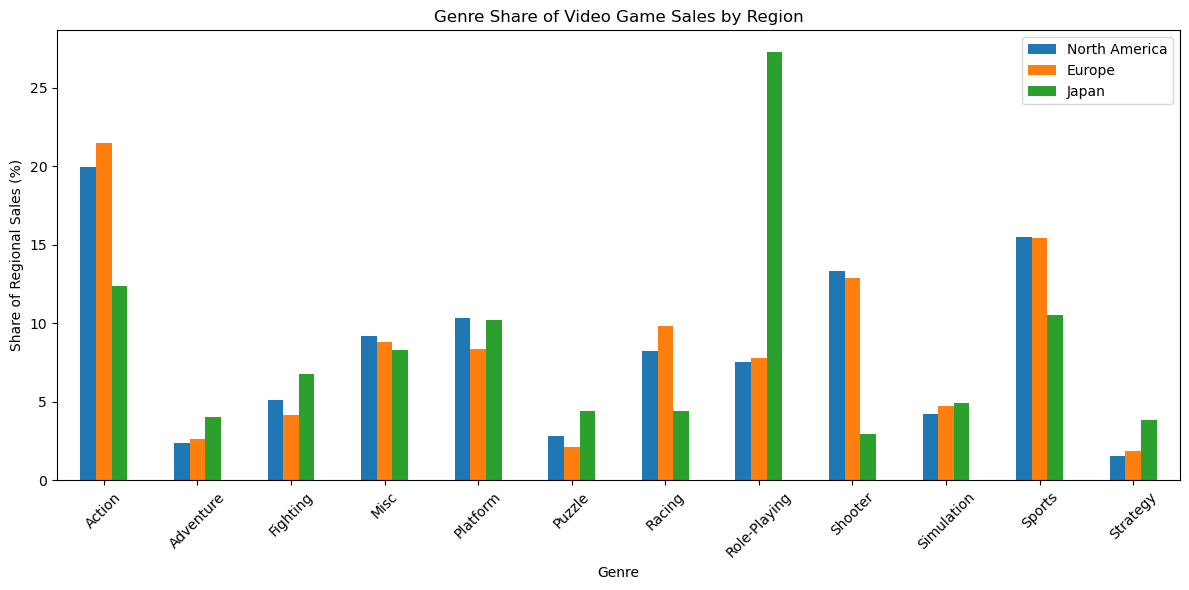

In [15]:
regional_genre_share.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Genre Share of Video Game Sales by Region")
plt.xlabel("Genre")
plt.ylabel("Share of Regional Sales (%)")
plt.xticks(rotation=45)
plt.legend(["North America", "Europe", "Japan"])
plt.tight_layout()

plt.show()

### Regional Market Insight

North America and Europe display relatively similar genre preferences,
with Action, Sports, and Shooter games accounting for substantial shares
of sales in both markets.

Japan shows a distinctly different market profile. Role-Playing games
account for approximately 27% of Japanese sales, compared with only
about 8% in North America and Europe. Shooter games show the opposite
pattern, representing a much smaller share of the Japanese market.

These results suggest that video game market strategies should account
for regional differences in genre preferences rather than applying the
same product strategy across all geographic markets.

In [ ]:
## 4. Publisher and Genre Performance

This analysis examines publisher performance across game genres to
identify publisher-genre combinations associated with strong historical
global sales.

In [16]:
publisher_genre_sales = (
    df.groupby(["Publisher", "Genre"])["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)

publisher_genre_sales.head(15)

Publisher             Genre       
Electronic Arts       Sports          468.69
Nintendo              Platform        426.18
Activision            Shooter         295.40
Nintendo              Role-Playing    284.57
                      Sports          218.01
Take-Two Interactive  Action          211.08
Nintendo              Misc            180.67
Electronic Arts       Shooter         158.26
Nintendo              Racing          151.30
Electronic Arts       Racing          145.77
Ubisoft               Action          142.94
Activision            Action          141.82
Nintendo              Action          128.10
                      Puzzle          124.88
Electronic Arts       Action          115.34
Name: Global_Sales, dtype: float64

In [17]:
publisher_genre_summary = (
    df.groupby(["Publisher", "Genre"])
    .agg(
        Game_Count=("Global_Sales", "size"),
        Total_Sales=("Global_Sales", "sum"),
        Median_Sales=("Global_Sales", "median")
    )
    .reset_index()
)

publisher_genre_summary.head()

,Publisher,Genre,Game_Count,Total_Sales,Median_Sales
0,10TACLE Studios,Adventure,1,0.02,0.02
1,10TACLE Studios,Puzzle,1,0.03,0.03
2,10TACLE Studios,Strategy,1,0.06,0.06
3,1C Company,Racing,1,0.04,0.04
4,1C Company,Role-Playing,1,0.01,0.01


In [18]:
reliable_publisher_genre = publisher_genre_summary[
    publisher_genre_summary["Game_Count"] >= 50
]

In [19]:
reliable_publisher_genre = (
    reliable_publisher_genre
    .sort_values("Median_Sales", ascending=False)
)

reliable_publisher_genre.head(15)

,Publisher,Genre,Game_Count,Total_Sales,Median_Sales
1158,Nintendo,Platform,111,426.18,1.750
1391,Sega,Platform,52,60.84,1.000
1164,Nintendo,Sports,55,218.01,1.000
1161,Nintendo,Role-Playing,105,284.57,0.980
1154,Nintendo,Action,78,128.10,0.750
1537,THQ,Fighting,71,72.86,0.750
1415,Sony Computer Entertainment,Platform,66,104.06,0.725
1419,Sony Computer Entertainment,Shooter,51,57.52,0.710
507,Electronic Arts,Shooter,139,158.26,0.590
1157,Nintendo,Misc,100,180.67,0.580


### Publisher-Genre Performance Insight

Electronic Arts Sports generated the highest cumulative sales among
publisher-genre combinations, but this performance was spread across
a large number of titles.

Nintendo Platform games achieved nearly comparable cumulative sales
with substantially fewer releases and had the highest median sales per
title among combinations containing at least 50 games.

Nintendo also ranked highly across several genres, suggesting that its
historical sales strength extended beyond a single market segment.

In [20]:
top_10_publisher_genre = reliable_publisher_genre.head(10).copy()

In [21]:
top_10_publisher_genre["Publisher_Genre"] = (
    top_10_publisher_genre["Publisher"]
    + " - "
    + top_10_publisher_genre["Genre"]
)

<Figure size 1000x600 with 0 Axes>

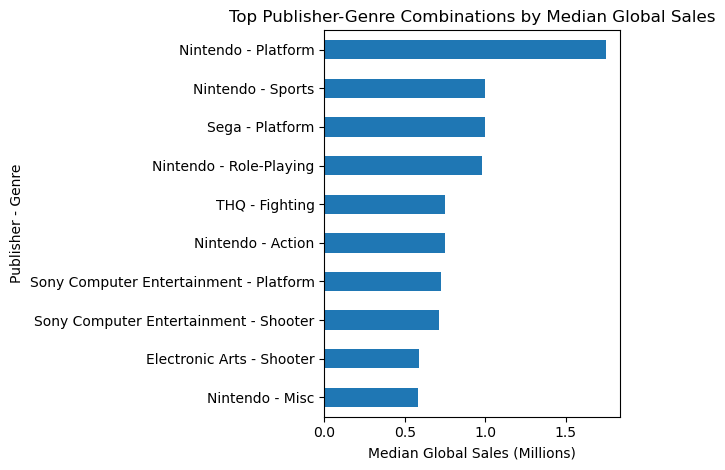

In [24]:
plt.figure(figsize=(10, 6))

top_10_publisher_genre.sort_values("Median_Sales").plot(
    x="Publisher_Genre",
    y="Median_Sales",
    kind="barh",
    legend=False
)

plt.title("Top Publisher-Genre Combinations by Median Global Sales")
plt.xlabel("Median Global Sales (Millions)")
plt.ylabel("Publisher - Genre")
plt.tight_layout()

plt.show()

## 5. Business Recommendations

Based on the historical sales analysis, several business recommendations
can be made.

### 1. Match Genre Strategy to Platform

Genre performance varies substantially across platforms. Shooter games
showed strong per-title performance on PS3 and Xbox 360, while other
platforms demonstrated strength in different genres.

Game development and publishing strategies should therefore consider
the historical relationship between genre and platform rather than
assuming that a successful genre will perform equally well across all
platforms.

### 2. Adapt Products to Regional Preferences

North America and Europe showed relatively similar genre preferences,
while Japan displayed a distinctly different market profile.

Role-Playing games represented a much larger share of Japanese sales,
while Shooter games represented a substantially smaller share.

Marketing and product strategies should therefore be adapted to
regional consumer preferences.

### 3. Consider Per-Title Performance Alongside Total Sales

High cumulative sales do not necessarily indicate stronger typical
performance. Several categories achieved high total sales primarily
because they contained large numbers of titles.

Median sales per game should therefore be considered alongside total
sales when evaluating historical market opportunities.

### 4. Publisher Specialization Can Be Valuable

Nintendo demonstrated particularly strong historical performance across
several genres, with Nintendo Platform games producing the highest
median sales among reliable publisher-genre combinations.

This suggests that publisher expertise, brand strength, and alignment
with particular genres may contribute to stronger market performance.

## 6. Limitations

Several limitations should be considered when interpreting the results.

- The dataset represents historical video game sales and may not reflect
  current market conditions or consumer preferences.

- Some later years contain very few observations, indicating incomplete
  coverage. Therefore, recent sales trends should be interpreted cautiously.

- The analysis identifies historical associations and patterns but does
  not establish causal relationships.

- A minimum threshold of 50 games was used when comparing median sales
  across genre-platform and publisher-genre combinations. This threshold
  was selected to reduce the influence of combinations with very small
  sample sizes and is not a universal statistical standard.

- Other factors that may influence sales, such as game quality, marketing
  spending, development budget, pricing, and release timing, are not
  included in the dataset.

## 7. Conclusion

The analysis demonstrates that video game sales performance depends on
multiple interacting factors rather than any single genre, platform,
publisher, or geographic market.

Genre-platform analysis showed that certain combinations historically
achieved stronger typical sales performance, while regional analysis
revealed meaningful differences in consumer preferences, particularly
between Japan and the North American and European markets.

Publisher analysis also showed that high cumulative sales can result
from different strategies. Some publishers achieved large sales through
high release volume, while others demonstrated stronger median sales
per title.

Overall, the findings suggest that business decisions should consider
platform fit, regional preferences, publisher strengths, and per-title
performance alongside cumulative sales.